<h1 style="color: #2E86C1; text-align: center;">Machine Learning - Architecture</h1>

In [1]:
import numpy as np

<h1 style="color: #2E86C1; text-align: center;">part 1: loading data</h1>

In [2]:

from sklearn import datasets
digits = datasets.load_digits()


In [3]:
all_images = digits.images
all_labels = digits.target

Text(0.5, 1.0, 'Label: 4')

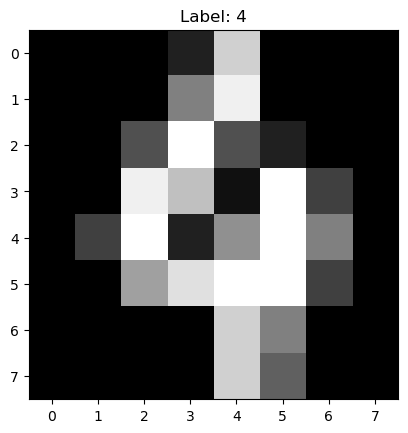

In [4]:
import matplotlib.pyplot as plt
img_number = 100
test_input = all_images[img_number]
test_target = all_labels[img_number]

plt.imshow(test_input, cmap='gray')
plt.title(f'Label: {test_target}')

In [5]:
all_images[5].max()

np.float64(16.0)

In [6]:
# 64 x 128 x 10

In [7]:
import torch

In [8]:
model = torch.nn.Sequential(
    torch.nn.Linear(64,128),
    torch.nn.ReLU(),
    torch.nn.Linear(128,64),
    torch.nn.ReLU(),
    torch.nn.Linear(64,10)
)

In [9]:
print(model)

Sequential(
  (0): Linear(in_features=64, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=10, bias=True)
)


In [21]:
lost_fun = torch.nn.CrossEntropyLoss() # this is for multi-class classification
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001) # this is for updating the weights of the model
total_images = len(all_images)
for epoch in range(100):
    for i in range(total_images):
        input = torch.tensor(all_images[i], dtype=torch.float32).view(1, -1)/16 # flatten the image to a vector of size 64
        target = torch.tensor([all_labels[i]], dtype=torch.long) # target should be a tensor of shape (1,)
        
        output = model(input) # forward pass
        loss = lost_fun(output, target) # compute the loss
        
        optimizer.zero_grad() # zero the gradients before backward pass
        loss.backward() # backward pass to compute gradients
        optimizer.step() # update the weights of the model
    if epoch % 1 == 0: # print loss every epoch"
        print(f'Epoch: {epoch+1}, Image: {i+1}/{total_images}, Loss: {loss.item():.4f}')







    

Epoch: 1, Image: 1797/1797, Loss: 1.4377
Epoch: 2, Image: 1797/1797, Loss: 1.4320
Epoch: 3, Image: 1797/1797, Loss: 1.4396
Epoch: 4, Image: 1797/1797, Loss: 1.4520
Epoch: 5, Image: 1797/1797, Loss: 1.4605
Epoch: 6, Image: 1797/1797, Loss: 1.4695
Epoch: 7, Image: 1797/1797, Loss: 1.4787
Epoch: 8, Image: 1797/1797, Loss: 1.4867
Epoch: 9, Image: 1797/1797, Loss: 1.4937
Epoch: 10, Image: 1797/1797, Loss: 1.4997
Epoch: 11, Image: 1797/1797, Loss: 1.5044
Epoch: 12, Image: 1797/1797, Loss: 1.5057
Epoch: 13, Image: 1797/1797, Loss: 1.5107
Epoch: 14, Image: 1797/1797, Loss: 1.5099
Epoch: 15, Image: 1797/1797, Loss: 1.5133
Epoch: 16, Image: 1797/1797, Loss: 1.5138
Epoch: 17, Image: 1797/1797, Loss: 1.5141
Epoch: 18, Image: 1797/1797, Loss: 1.5126
Epoch: 19, Image: 1797/1797, Loss: 1.5145
Epoch: 20, Image: 1797/1797, Loss: 1.5163
Epoch: 21, Image: 1797/1797, Loss: 1.5179
Epoch: 22, Image: 1797/1797, Loss: 1.5199
Epoch: 23, Image: 1797/1797, Loss: 1.5225
Epoch: 24, Image: 1797/1797, Loss: 1.5271
E

0


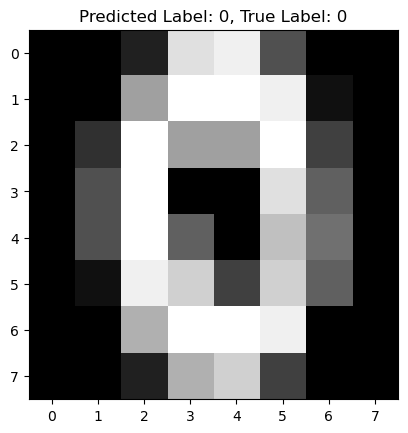

In [22]:
img_number = 55
sample_image = all_images[img_number]
img_torch = torch.tensor(sample_image, dtype=torch.float32)
img_extend = img_torch.flatten()
sample_image_tensor = img_extend.float()  / 16

predict_output = model(sample_image_tensor)
predicted_label = torch.argmax(predict_output).item()


print(predicted_label)

plt.imshow(sample_image, cmap='gray')
plt.title(f'Predicted Label: {predicted_label}, True Label: {all_labels[img_number]}')
plt.show()

<body style="font-family:Arial,sans-serif;background:#f4f6f9;padding:30px;color:#222;">

<div style="max-width:700px;margin:auto;background:white;padding:25px;border-radius:12px;box-shadow:0 4px 10px rgba(0,0,0,0.1);">

<h1 style="color:#2c3e50;text-align:center;">Training Summary</h1>

<h2 style="color:#34495e;">Loop Order</h2>
<p style="line-height:1.6;">
Changed from 
<code style="background:#eee;padding:3px 6px;border-radius:5px;">image → epoch</code>
to
<code style="background:#eee;padding:3px 6px;border-radius:5px;">epoch → image</code>.
This improved learning stability.
</p>

<h2 style="color:#34495e;">Normalization</h2>
<p style="line-height:1.6;">
Dividing inputs by 
<code style="background:#eee;padding:3px 6px;border-radius:5px;">16</code>
made training smoother.
</p>

<h2 style="color:#34495e;">Learning Rate</h2>
<p style="line-height:1.6;">
Reduced learning rate from 
<code style="background:#eee;padding:3px 6px;border-radius:5px;">0.01</code>
to
<code style="background:#eee;padding:3px 6px;border-radius:5px;">0.0001</code>
for more stable updates.
</p>

<h2 style="color:#34495e;">Average Loss</h2>
<p style="line-height:1.6;">
Using average epoch loss gives a better understanding of training progress.
</p>

<h2 style="color:#34495e;">Final Result</h2>
<ul style="line-height:1.8;">
<li>More stable training</li>
<li>Smoother loss reduction</li>
<li>Better predictions</li>
</ul>

</div>

</body>

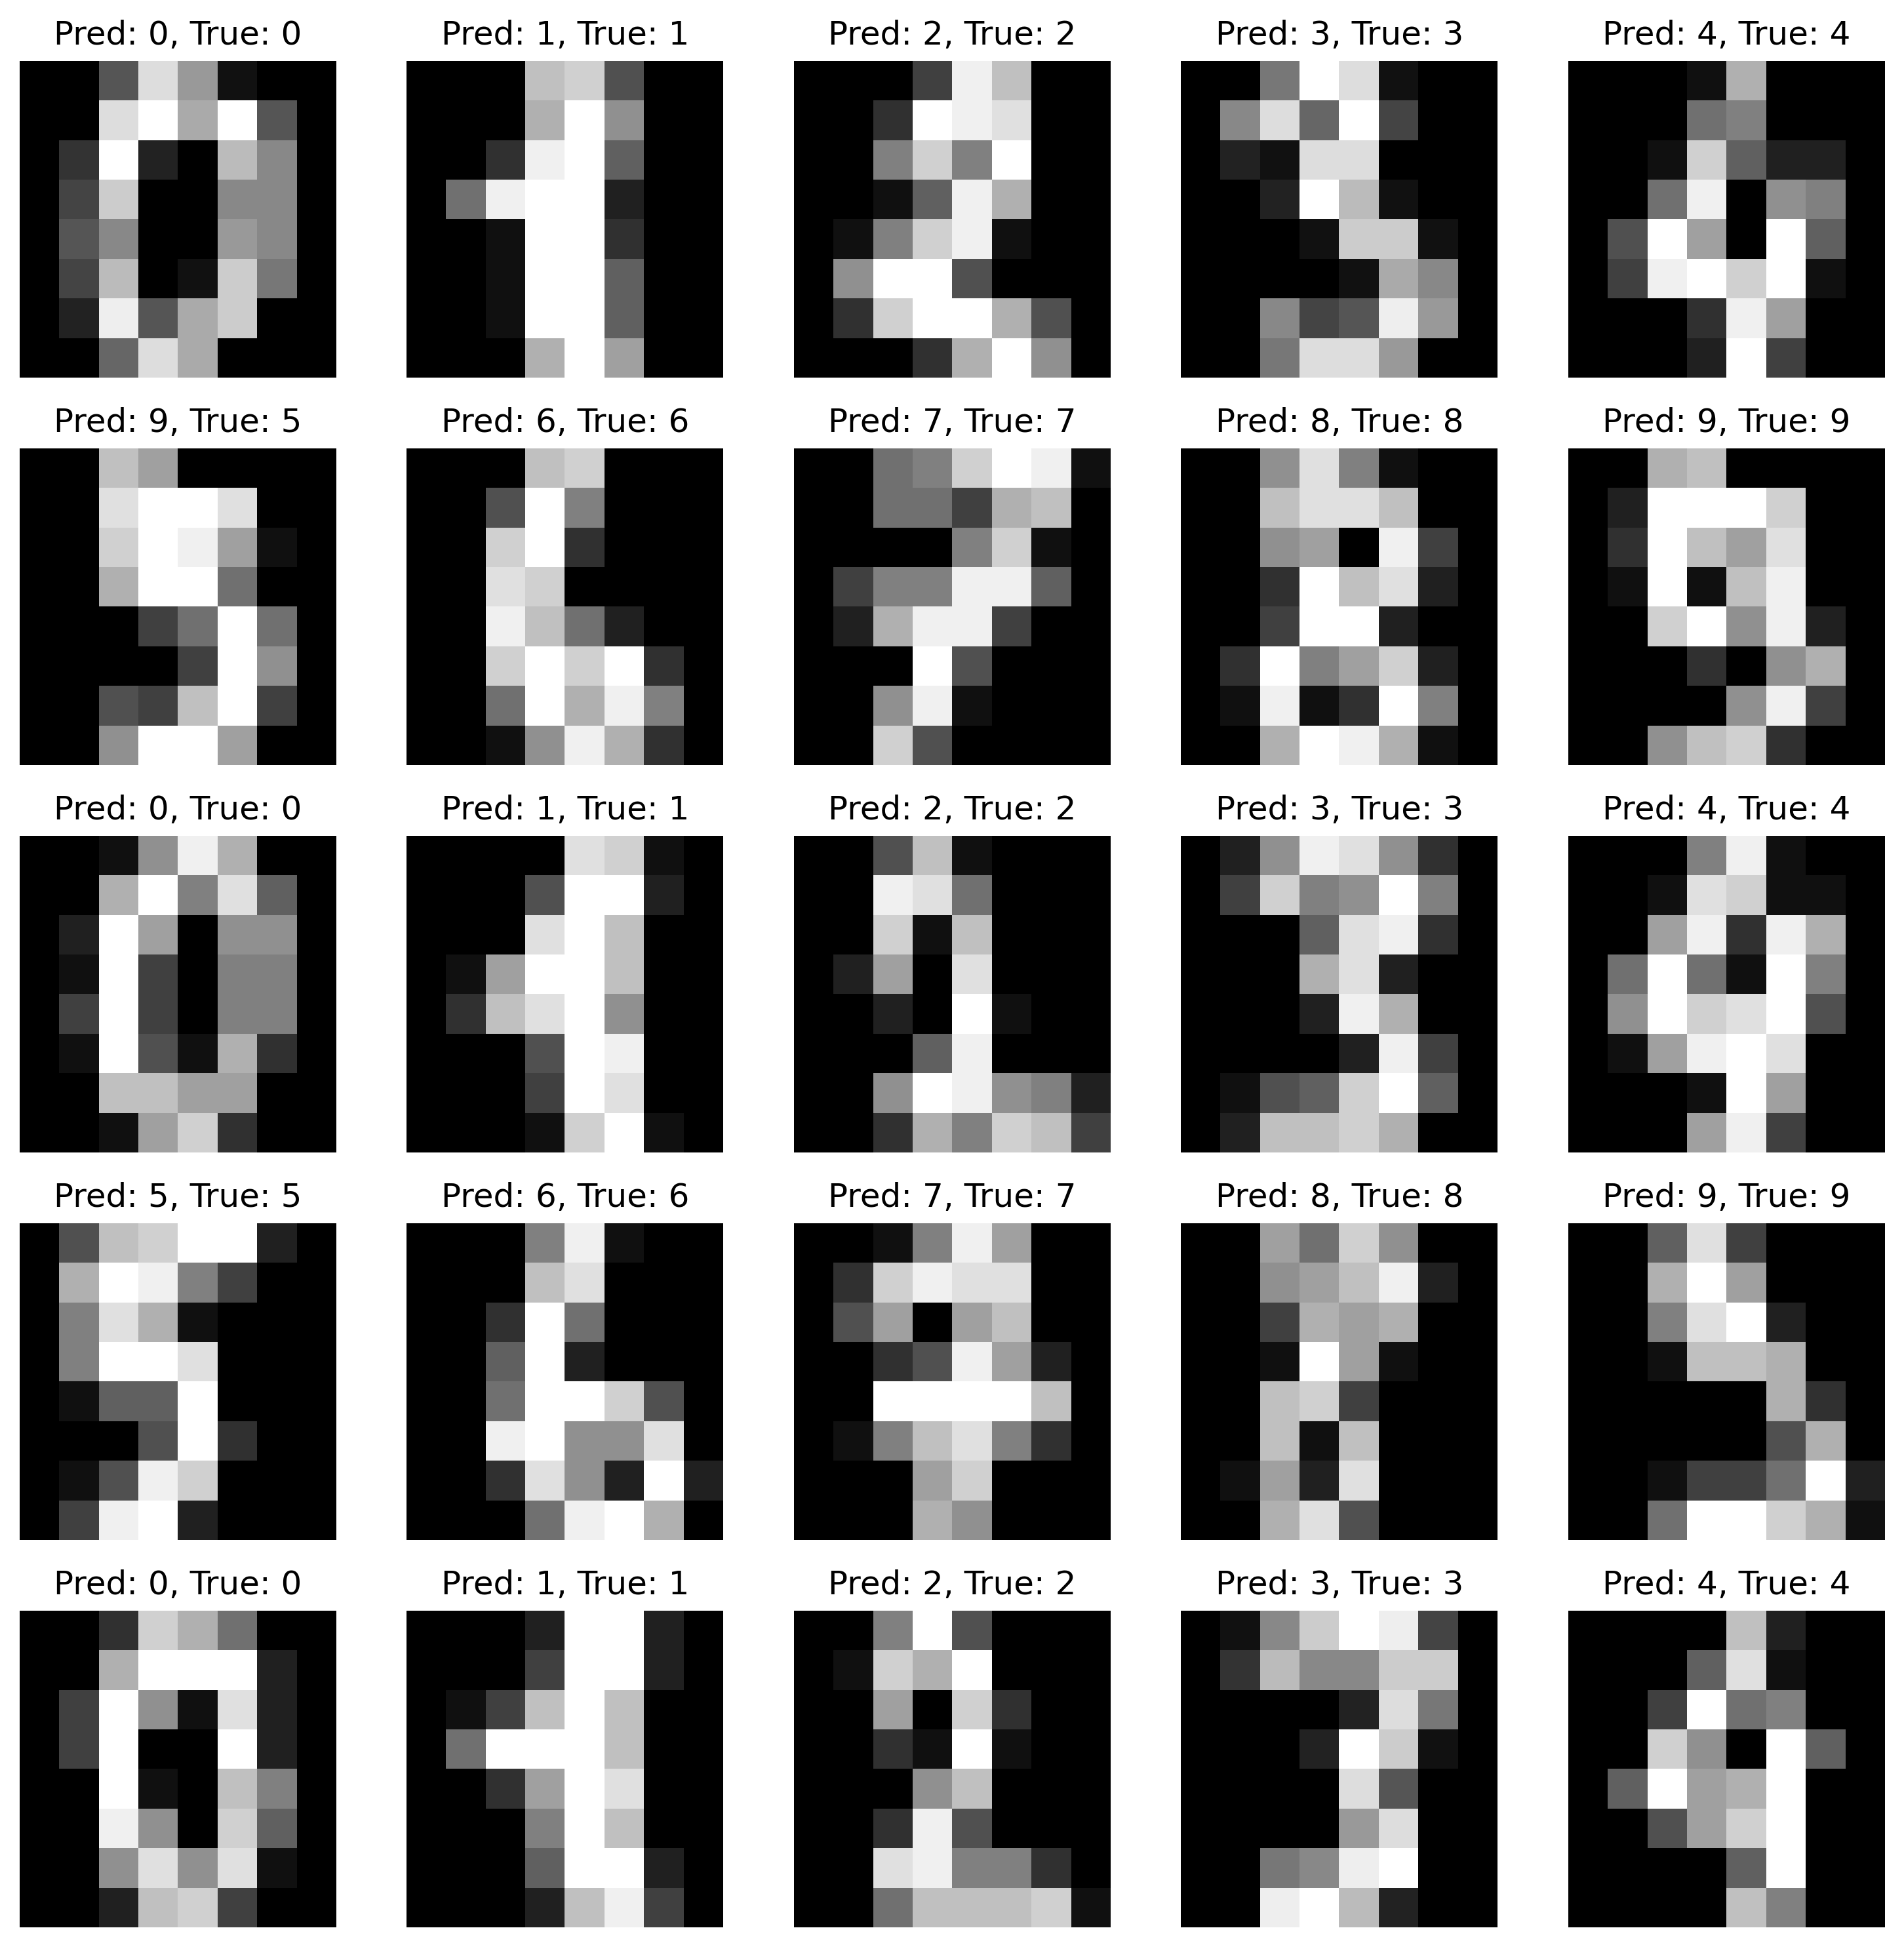

In [25]:
r = 5
c = 5

fig, axes = plt.subplots(r, c, figsize=(10, 10),dpi=300)
for i in range(r):
    for j in range(c):
        ax = axes[i, j]
        ax.axis('off')
        img_number = i * c + j
        sample_image = all_images[img_number]
        ax.imshow(sample_image, cmap='gray')
        img_torch = torch.tensor(sample_image, dtype=torch.float32)
        img_extend = img_torch.flatten()
        sample_image_tensor = img_extend.float()  / 16
        predict_output = model(sample_image_tensor)
        predicted_label = torch.argmax(predict_output).item()
        ax.set_title(f'Pred: {predicted_label}, True: {all_labels[img_number]}')
plt.tight_layout()

